# Imports

In [1]:
# Active libraries

import numpy as np                          # to work with arrays
import matplotlib.pyplot as plt             # to plot
import copy                                 # to copy objects
import sys                                  # to change the path
sys.path.insert(1, '/home/abha2208/py_mesa_reader-master')  # to locate mesa_reader
import mesa_reader as mr                    # to import MESA reader

plt.rcParams["mathtext.fontset"] = "cm"     # to use Latex in plots

# Inactive libraries

import scipy.interpolate as sp              # to interpolate
from scipy.signal import convolve2d         # to convolve
from scipy.signal import savgol_filter      # to smooth

### In this document, all variables will be in cgs units by default, unless otherwise specified.

# Constants

In [21]:
#constants

G_const = 6.6743 * pow(10,-8)           #g^-1 cm^3 s^-2 
M_sun = 1.9891 * pow(10,33)             #g
R_sun = 6.957 * pow(10,10)              #cm
c = 3 * pow(10,10)                      #cm s^-1


#model parameters

M_ns = 1.33 * M_sun                     #g
R_ns = 1000000                          #cm
f0 = 250                                #Hz
omega0 = f0*2*np.pi                     #Hz
e0 = 0.177
p_0 = 1/f0                              #s

eta1 = 1
eta2 = 0.1
alpha_ce = 1
R_eq = 10**6                                  #cm
R_const = (8.31 * 10**7) / (6.022 * 10**(23)) #erg/K

#conversions

s_to_yr = 3.17098 * pow(10,-8)
yr_to_s = 3.154 * 10**7
pc_to_cm = 3.086 * pow(10,18)

# General Functions

In [22]:
# to multiply a 1D array with a 2D array
def multiply_1d_array_to_2d_array(arr1d, arr2d):
    if arr1d.shape[0] != arr2d.shape[0]:
        raise ValueError("The 1D array and 2D array must have the same number of rows.")
    # Reshape the 1D array to have the same number of dimensions as the 2D array
    arr1d_reshaped = arr1d.reshape(-1, 1)
    # Multiply the reshaped 1D array with the 2D array
    result = arr1d_reshaped * arr2d
    return result

# to integrate a 1D array using the trapezoidal rule
def integ1d_trapz(f, x):
    dx = np.diff(x)
    return np.insert(np.cumsum((f[1:]+f[:-1])*dx/2), 0, 0)

# to differentiate a 1D array using the second order central difference method
def diff1d(f, x):
    diff = np.array([])
    first = ((2*x[0] - x[1] - x[2]) / ((x[1] - x[0]) * (x[2] - x[0]))) * f[0] + ((x[2] - x[0]) / ((x[1] - x[0]) * (x[2] - x[1]))) * f[1] + ((x[0] - x[1]) / ((x[2] - x[1]) * (x[2] - x[0]))) * f[2]
    between = [(x[1:-1] - x[2:]) / ((x[2:] - x[:-2]) * (x[1:-1] - x[:-2]))] * f[:-2]  +  [(2 * x[1:-1] - x[:-2] - x[2:]) / ((x[1:-1] - x[:-2]) * (x[1:-1] - x[2:]))] * f[1:-1]  +  [(x[1:-1] - x[:-2]) / ((x[2:] - x[:-2]) * (x[2:] - x[1:-1]))] * f[2:]
    last = ((x[-1] - x[-2]) / ((x[-1] - x[-3]) * (x[-2] - x[-3]))) * f[-3]  +  ((x[-3] - x[-1]) / ((x[-2] - x[-3]) * (x[-1] - x[-2]))) * f[-2]  +  ((2 * x[-1] - x[-2] - x[-3]) / ((x[-1] - x[-2]) * (x[-1] - x[-3]))) * f[-1]
    diff = np.append(diff, first)
    diff = np.append(diff, between)
    diff = np.append(diff, last)
    return diff

############################################################################################################
# [not used in the code, but kept for reference]

# to differentiate a 1D array using the 10th order central difference method
def diff1d_10(f, dx):
    func_arr = np.array([f[:-10], f[1:-9], f[2:-8], f[3:-7], f[4:-6], f[6:-4], f[7:-3], f[8:-2], f[9:-1], f[10:]])
    coeff_arr = np.array([-2,25,-150,600,-2100,2100,-600,150,-25,2])
    diff = multiply_1d_array_to_2d_array(coeff_arr,func_arr)/(2520*dx)
    return np.sum(diff, axis=0)

# to differentiate a 1D array (f(x)) with even spacing in x using the 2th order central difference method
def diff1d_simple_even(f, dx):
    first = (-3*f[0] + 4*f[1] - f[2])/(2*dx)
    between = (f[2:] - f[:-2])/(2*dx)
    last = (f[-3] - 4*f[-2] + 3*f[-1])/(2*dx)
    diff = np.concatenate((np.array([first]), between, np.array([last])))
    return diff

# to differentiate a 1D array (f(x)) with eneven spacing in x using the 2th order central difference method
def diff1d_simple_uneven(f, x):
    diff = (f[1:] - f[:-1])/(x[1:] - x[:-1]) 
    return diff

# # to smooth a function using the Savitzky-Golay filter
# def smoothen(function, window, order, iter = 1):
#     i = 1
#     smoothed_function = savgol_filter(function, window, order)
#     while i < iter:
#         smoothed_function = savgol_filter(smoothed_function, window, order)
#         i+=1
#     return smoothed_function

# Model Functions

These functions are used to calculate the model parameters. Their function, in order of appearance, is as follows:

1. mass_env: calculates the mass of the envelope of the primary [not in use]
2. v_inf: calculates the orbital velocity of the secondary
3. back_density_gradient: calculates the gradient of the density of the envelope
4. drag_hl: calculates the hoyle-lyttleton drag force acting on the secondary
5. acc_hl: calculates the hoyle-lyttleton accretion rate of the secondary
6. drag_ratio_mr15: calculates the drag ratio from the MR15 model
7. acc_rate_ratio_mr15: calculates the accretion rate ratio from the MR15 model
8. mdot_edd: calculates the Eddington accretion rate
9. mdot_hyper: calculates the hypercritical accretion rate
10. e_orbital: calculates the orbital energy of the secondary
11. mdot_compare: compares the accretion rate from the MR15 model to the Eddington and hypercritical accretion rates
12. e_bind: calculates the binding energy of the envelope [not in use]
13. e_internal: calculates the internal energy of the envelope
14. find_stopping_index: finds the index where the evolution should stop
15. orbit_evol: calculates the orbital evolution of the secondary
16. acc_mass: calculates the mass accreted by the secondary
17. spin_param_from_e: calculates the spin parameter from the eccentricity
18. spin_from_e: calculates the spin of the secondary from the eccentricity
19. equitorial_radius: calculates the equitorial radius of the secondary from the eccentricity
20. spin_solve: solves for the eccentricity given the spin of the secondary
21. spin_evol: evolves the spin and quadrupole moment of the neutron star

#### UNLESS OTHERWISE SPECIFIED, ALL PASSED AND RETURNED ARRAYS START FROM THE SURFACE TO THE CORE OF THE PRIMARY STAR.

Note that some operations like integration must be performed from the core to the surface, so within the functions, sometimes we need to flip the arrays to run from the core to the surface. In the end though, it is best to ensure that the arrays that are passed to the function and the array returned by those functions run from the surface to the core for self consistency. 

Running from surface to core, although sounds weird, is more convinient because the secondary is moving in from the surface towards the core.

In [23]:
# the equations of the paper that correspond to the functions are given below

# equation 28
def mass_env(rho, a):
    return integ1d_trapz(4*np.pi*rho*(a**2), a)                               #g

# equation 28
def v_inf(m_env, a, a_num = None):
    v_inf_sq = G_const*(M_ns + m_env)/a                                       #cm^2 s^-2
    if a_num == None:
        return np.sqrt(v_inf_sq)                                        #cm^2 s^-2
    else:
        index = np.where(a >= a_num)
        return np.sqrt(v_inf_sq)[index[0][0]]                           #cm^2 s^-2
    
# equation 13
def back_density_grad(Ra, rho, a):
    return -1*(np.divide(Ra,rho))*diff1d(rho, a)

# equation 9a
def drag_hl(Ra, rho, v):
    return np.pi*(Ra**2)*rho*(v**2)

# equation 8
def acc_hl(Ra, rho, v):
    return np.pi*(Ra**2)*rho*v

# equation 20
def drag_ratio_mr15(eps_rho, f1 = 1.91791946, f2 = -1.52814698, f3 = 0.75992092):    
    return f1 + f2*eps_rho + f3*np.power(eps_rho,2)

def kim2010(v, csound, a_in, Ra_in, rho):
    mach = v/csound
    beta = G_const*M_ns/(a_in*(csound**2))
    eta_b = beta/(mach**2 - 1)
    rho_nl = rho*(1 + (0.46*(beta**1.1))/(mach**2 - 1)**0.11)
    cd = 1
    
    if mach < 1.01:
        i_var = 0.7706*np.log((1+mach)/(1.0004 - 0.9185*mach)) - 1.473*mach
    elif mach >= 1.01 and mach < 4.4:
        i_var = np.log(330*(a_in*(mach-0.71)**5.72)/(Ra_in*mach**9.58))
    else:
        i_var = np.log(a_in / (Ra_in*(0.11*mach + 1.65)))
    
    if eta_b > 0.1 and mach > 1.01:
        fd_out = cd * (4 * np.pi * rho_nl * ((G_const * M_ns / v)**2) ) * (0.7 / eta_b**0.5)
    else:
        fd_out = cd * (4 * np.pi * rho * ((G_const * M_ns / v)**2) ) * i_var

    return fd_out

def kim2010_arr(v, csound, a_in, Ra_in, rho):
    mach = v/csound
    fd_out = np.zeros(len(mach))
    i_var = np.zeros(len(mach))
    beta = G_const*M_ns/(a_in*(csound**2))
    eta_b = beta/(mach**2 - 1)
    regime = np.zeros(len(mach))
    rho_nl = rho*(1 + (0.46*(beta**1.1))/(mach**2 - 1)**0.11)
    cd = 1

    for i in range(len(mach)):
        if mach[i] < 1.01:
            i_var[i] = 0.7706*np.log((1+mach[i])/(1.0004 - 0.9185*mach[i])) - 1.473*mach[i]
            # print(1)
        elif mach[i] >= 1.01 and mach[i] < 4.4:
            i_var[i] = np.log(330*(a_in[i]*(mach[i]-0.71)**5.72)/(Ra_in[i]*mach[i]**9.58))
            # print(2)
        else:
            i_var[i] = np.log(a_in[i] / (Ra_in[i]*(0.11*mach[i] + 1.65)))
            # print(3)
        
        if eta_b[i] > 0.1 and mach[i] > 1.01:
            fd_out[i] = cd * (4 * np.pi * rho_nl[i] * ((G_const * M_ns / v[i])**2) ) * (0.7 / eta_b[i]**0.5)
            regime[i] = 1
        else:
            fd_out[i]  = cd * (4 * np.pi * rho[i] * ((G_const * M_ns / v[i])**2) ) * i_var[i]
            regime[i]= 0

    return fd_out, regime

# equation 22
def acc_rate_ratio_mr15(eps_rho, mu1 = -2.14034214, mu2 = 1.94694764, mu3 = 1.19007536, mu4 = 1.05762477):
    return np.power(10, mu1 + mu2/(1 + mu3*eps_rho + mu4*(eps_rho**2)))

# equation 3
def mdot_edd(opacity):
    return 3.5*(10**(-8))*(M_ns/(1.33*M_sun))*(0.34/opacity)*M_sun/yr_to_s        #g s^-1

# equation 12
def mdot_hyper(opacity):
    return 8.9*(10**(-5))*np.power(opacity/0.34, -0.73)*M_sun/yr_to_s                #g s^-1

# equation 29
def e_orbital(m_env, a):
    return -G_const*M_ns*m_env/(2*a)

# equation 24
def mdot_compare(mdot_mr15, eta, mdot_edd, mdot_hyper):
    mdot = copy.deepcopy(mdot_edd)
    index_btw = np.where(np.logical_or(eta*mdot_mr15 <= mdot_edd, eta*mdot_mr15 >= mdot_hyper))
    if index_btw[0].size > 0:
        mdot[index_btw[0]] = eta*mdot_mr15[index_btw[0]]
    return mdot, index_btw

# [not in use] equation 31
def e_bind(m_env, a):
    # index = np.where(a >= af)
    dm = np.diff(m_env)
    # indice = np.delete(np.array(index[0]), 0)
    summand = -1*np.divide(G_const*m_env[1:]*dm,a[1:]) #+ 3*R_const*dm*(T[-1] - T[1:])/2
    integral = np.cumsum(summand)                                               
    return integral[-1] - integral

# equation 31
def e_inernal(etot, m_env):
    integrand = np.flip(etot)
    var = np.flip(m_env)
    diff = np.diff(var)
    temp_integral = np.insert(np.cumsum((integrand[1:]+integrand[:-1])*diff/2), 0, 0)
    return np.flip(temp_integral[-1] - temp_integral)

# equation 30
def find_stopping_index(deorb, ebind):
    difference = deorb + ebind
    sign_change = np.where((difference[:-1] <= 0) & (difference[1:] > 0))[0]
    if sign_change[0] == 0:
        return sign_change[1] + 1
    else:
        return sign_change[0] + 1

# equation 26
def orbit_evol(drag, v, a, diff_eorb, i, f):
    integrand = -diff_eorb[i:f]/(drag[i:f]*v[i:f])
    da = np.diff(a[i:f])
    return np.insert(np.cumsum((integrand[1:]+integrand[:-1])*da/2), 0, 0)

def acc_mass(mdot, time):
    dt = np.diff(time)
    return np.insert(np.cumsum((mdot[1:]+mdot[:-1])*dt/2), 0, 0)

# equation 34
def spin_param_from_e(e):
    return 3*(1 - e*np.sqrt(1 - e**2)/np.arcsin(e))/(2*e**2) - 1

# equation 35
def spin_from_e(M, R0, e, n=0.5, kn = 0.81482):
    rho_bar = 3*M/(4*np.pi*R0**3)
    qn = (1-n/5)*kn
    omega_sq = 2*np.pi*G_const*(rho_bar)*(((np.sqrt(1-e**2))*(3-2*e**2)*(np.arcsin(e))/(e**3)) - (3*(1-e**2)/(e**2)))/qn
    return np.sqrt(omega_sq)

# equation 37
def equitorial_radius(R0, e, n = 0.5):
    R_bar = R0*((np.arcsin(e))*((1-e**2)**(1/6))*(1-spin_param_from_e(e))/e)**(-n/(3-n))
    return R_bar/((1-e**2)**(1/6))

# equation 35 but solving for eccentricity given some omega or spin
def spin_solve(M, R0, ein, omega_val, tol):
    iterations = 0
    e1 = ein
    omega1 = spin_from_e(M, R0, e1)
    while (abs(omega1 - omega_val) > tol and iterations < 100):
        e1 = e1*omega_val/omega1
        omega1 = spin_from_e(M, R0, e1)
        iterations += 1
    eout = e1
    return eout

# solving equation 17 for spin + other equations inside the function
def spin_evol(t, mdot, m_acc, e0 = 0.177, omega0 = 250*2*np.pi, M_ns = 1.33*M_sun, R_ns = 1000000, m_crust = 0.05*M_sun, n = 0.5, kn = 0.81482, melt = True):

    #initialising arrays

    omega_evol = np.array([])           #spin evolution
    Q_evol = np.array([])               #quadrupole moment evolution
    e_evol = np.array([])               #eccentricity evolution
    R_eq_evol = np.array([])            #equitorial radius evolution
    mom_inrt_evol = np.array([])        #moment of inertia evolution
    a_evol = np.array([])               #semi-major axis evolution
    b_evol = np.array([])               #semi-minor axis evolution
    rhs_arr_evol = np.array([])         #right hand side of the equation 17 (including the moment of inertia on the rhs)
    melt_param_evol = np.array([])      #melt parameter evolution

    M_evol = np.array([M_ns])           #mass of secondary evolution. 1st element is the mass it starts out with
    
    tau_melt = 0.05*M_sun/mdot
    Q_max = 4 * 10**(39) * (m_acc/m_crust)
    Q_tb = np.sqrt(5*(c**5)*mdot[0]*np.sqrt(G_const*M_ns*equitorial_radius(R_ns, e0))/(32*G_const*(omega0**5)))

    M_evol = np.append(M_evol, M_ns + m_acc)    #the evolution of the mass of secondary is already determined by knowing the evolution of the accreted mass 

    #loop over the time array to solve for the spin and quadrupole moment evolution
    for i in range(len(t)):
        # for the first time step we know all the variables because we assume the secondary is in torque balance
        if i==0:
            R_eq_evol = np.append(R_eq_evol, equitorial_radius(R_ns, e0))
            Q_evol = np.append(Q_evol, Q_tb)
            omega_evol = np.append(omega_evol, omega0)
            e_evol = np.append(e_evol, e0)
            a_evol = np.append(a_evol, R_ns*(1 + e_evol[i]/2))
            b_evol = np.append(b_evol, R_ns*(1 - e_evol[i]/2))
            mom_inrt_evol = np.append(mom_inrt_evol, (M_evol[i])*(a_evol[i]**2 + b_evol[i]**2)/5)   #equation 16
            rhs = 0
            rhs_arr_evol = np.append(rhs_arr_evol, rhs)
            melt_param_evol = np.append(melt_param_evol, 1)
        else:
            # for the rest of the time steps we solve for the spin and quadrupole moment evolution by solving equation 17
            e_evol = np.append(e_evol, spin_solve(M_evol[i], R_ns, e_evol[i-1], omega_evol[i-1], 0.01))
            a_evol = np.append(a_evol, R_ns*(1 + e_evol[i]/2))
            b_evol = np.append(b_evol, R_ns*(1 - e_evol[i]/2))
            mom_inrt_evol = np.append(mom_inrt_evol, (M_evol[i])*(a_evol[i]**2 + b_evol[i]**2)/5)
            R_eq_evol = np.append(R_eq_evol, equitorial_radius(R_ns, e_evol[i]))
            rhs = (mdot[i-1]*np.sqrt(G_const*(M_evol[i-1])*R_eq_evol[i-1]) - 32*G_const*(omega_evol[i-1]**5)*(Q_evol[i-1]**2)/(5*(c**5)))/mom_inrt_evol[i-1] #equation 17
            rhs_arr_evol = np.append(rhs_arr_evol, rhs)
            omega_evol = np.append(omega_evol, rhs*(t[i] - t[i-1]) + omega_evol[i-1])
            Q_tb = np.sqrt(5*(c**5)*mdot[i]*np.sqrt(G_const*(M_evol[i])*R_eq_evol[i])/(32*G_const*(omega_evol[i]**5)))

            # equation 41. This condition essentially says that if the quadrupole moment needed by the NS 
            # to be in torque balance is greater than the maximum quadrupole moment it can have, then the NS
            # can only keep the maximum quadrupole moment it can have. We can choose whether the NS melts or not
            # using the melt parameter. If melt is True, then the NS melts and the quadrupole moment decays.
            if Q_tb > Q_max[i-1]:
                if melt:
                    Q_evol = np.append(Q_evol, Q_max[i-1]*np.exp(-t[i]/tau_melt[i]))
                else:
                    Q_evol = np.append(Q_evol, Q_max[i-1])
            else:
                Q_evol = np.append(Q_evol, Q_tb)
                # if we also include melting in torque balance, then the quadrupole moment decays exponentially
                # if melt:
                #     Q_evol = np.append(Q_evol, Q_tb*np.exp(-t[i]/tau_melt[i]))
                # else:
                #     Q_evol = np.append(Q_evol, Q_tb)
            # I have assumed a melting prescription of the kind exp(-t/tau_melt) where tau_melt is the melting time scale.
            # outputting it just in case it is needed.
            melt_param_evol = np.append(melt_param_evol, np.exp(-t[i]/tau_melt[i]))
            
    return Q_evol, omega_evol, e_evol, R_eq_evol, mom_inrt_evol, a_evol, b_evol, rhs_arr_evol, melt_param_evol

def spin_evol_3(t, mdot, m_acc, e0 = 0.177, omega0 = 250*2*np.pi, M_ns = 1.33*M_sun, R_ns = 1000000, m_crust = 0.05*M_sun, n = 0.5, kn = 0.81482, melt = True):

    #initialising arrays

    omega_evol = np.array([])           #spin evolution
    Q_evol = np.array([])               #quadrupole moment evolution
    e_evol = e0               #eccentricity evolution
    R_eq_evol = equitorial_radius(R_ns, e0)            #equitorial radius evolution
    mom_inrt_evol = np.array([])        #moment of inertia evolution
    # a_evol = np.array([])               #semi-major axis evolution
    # b_evol = np.array([])               #semi-minor axis evolution
    rhs_arr_evol = np.array([])         #right hand side of the equation 17 (including the moment of inertia on the rhs)
    melt_param_evol = np.array([])      #melt parameter evolution

    M_evol = np.array([M_ns])           #mass of secondary evolution. 1st element is the mass it starts out with
    
    Q_max = 4 * 10**(39) * (m_acc/m_crust)
    Q_tb = np.sqrt(5*(c**5)*mdot[0]*np.sqrt(G_const*M_ns*equitorial_radius(R_ns, e0))/(32*G_const*(omega0**5)))

    M_evol = np.append(M_evol, M_ns + m_acc)    #the evolution of the mass of secondary is already determined by knowing the evolution of the accreted mass 

    #loop over the time array to solve for the spin and quadrupole moment evolution
    for i in range(len(t)):
        # for the first time step we know all the variables because we assume the secondary is in torque balance
        if i==0:
            Q_evol = np.append(Q_evol, Q_tb)
            omega_evol = np.append(omega_evol, omega0)
            # a_evol = np.append(a_evol, R_ns*(1 + e_evol[i]/2))
            # b_evol = np.append(b_evol, R_ns*(1 - e_evol[i]/2))
            mom_inrt_evol = np.append(mom_inrt_evol, (2*M_evol[i]/5) * R_ns**2 )   #equation 16
            rhs = 0
            rhs_arr_evol = np.append(rhs_arr_evol, rhs)
        else:
            # for the rest of the time steps we solve for the spin and quadrupole moment evolution by solving equation 17
            # a_evol = np.append(a_evol, R_ns*(1 + e_evol[i]/2))
            # b_evol = np.append(b_evol, R_ns*(1 - e_evol[i]/2))
            mom_inrt_evol = np.append(mom_inrt_evol, (2*M_evol[i]/5) * R_ns**2 )
            rhs = (mdot[i-1]*np.sqrt(G_const*(M_evol[i-1])*R_eq_evol) - 32*G_const*(omega_evol[i-1]**5)*(Q_evol[i-1]**2)/(5*(c**5)))/mom_inrt_evol[i-1] #equation 17
            rhs_arr_evol = np.append(rhs_arr_evol, rhs)
            omega_evol = np.append(omega_evol, rhs*(t[i] - t[i-1]) + omega_evol[i-1])
            Q_tb = np.sqrt(5*(c**5)*mdot[i]*np.sqrt(G_const*(M_evol[i])*R_eq_evol)/(32*G_const*(omega_evol[i]**5)))

            # equation 41. This condition essentially says that if the quadrupole moment needed by the NS 
            # to be in torque balance is greater than the maximum quadrupole moment it can have, then the NS
            # can only keep the maximum quadrupole moment it can have. We can choose whether the NS melts or not
            # using the melt parameter. If melt is True, then the NS melts and the quadrupole moment decays.
            if Q_tb > Q_max[i-1]:
                Q_evol = np.append(Q_evol, Q_max[i-1])
            else:
                Q_evol = np.append(Q_evol, Q_tb)
                # if we also include melting in torque balance, then the quadrupole moment decays exponentially
                # if melt:
                #     Q_evol = np.append(Q_evol, Q_tb*np.exp(-t[i]/tau_melt[i]))
                # else:
                #     Q_evol = np.append(Q_evol, Q_tb)
            # I have assumed a melting prescription of the kind exp(-t/tau_melt) where tau_melt is the melting time scale.
            # outputting it just in case it is needed.
            
    return Q_evol, omega_evol

# [not in use] In progress. These functions should be able to just read a MESA file and give the plots directly. They are not much 
# useful as of now because making any modifications inside a function is more complicated at this stage.
def orbit_evol_acc(a, rho, m_env, im_ns, scl_hgt, eta, mdot_hyper, mdot_edd, ns_add = True, f1 = 1.91791946, f2 = -1.52814698, f3 = 0.75992092, mu1 = -2.14034214, mu2 = 1.94694764, mu3 = 1.19007536, mu4 = 1.05762477):
    m_ns = np.array([])
    v = np.array([])
    Ra = np.array([])
    eps_rho = np.array([])

    #drag
    drag_hl = np.array([])
    drag_ratio = np.array([])
    drag_mr15 = np.array([])

    #accretion
    mdot_hl = np.array([])
    mdot_ratio = np.array([])
    mdot_mr15 = np.array([])

    #orbital energy
    eorb = np.array([])
    deorb = np.array([])

    #accretion rate parametrization and drag
    mdot = np.array([])
    drag = np.array([])

    #adding accretion to neutron star
    if ns_add:
        m_ns_acc = np.array([])

    #time
    time = np.array([])

    for i in range(len(a)):
        if i == 0:
            temp_m_ns = im_ns
        else:
            temp_m_ns = m_ns[i-1]
        v = np.append(v, np.sqrt(G_const*(temp_m_ns + m_env[i])/a[i]))
        Ra = np.append(Ra, 2*G_const*temp_m_ns/(v[i]**2))
        eps_rho = np.append(eps_rho, Ra[i]/scl_hgt[i])


        #drag and accretion
        drag_hl = np.append(drag_hl, np.pi*(Ra[i]**2)*rho[i]*(v[i]**2))
        mdot_hl = np.append(mdot_hl, np.pi*(Ra[i]**2)*rho[i]*v[i])

        drag_ratio = np.append(drag_ratio, f1 + f2*eps_rho[i] + f3*pow(eps_rho[i],2))
        mdot_ratio = np.append(mdot_ratio, pow(10, mu1 + mu2/(1 + mu3*eps_rho[i] + mu4*(eps_rho[i]**2))))

        drag_mr15 = np.append(drag_mr15, drag_ratio[i]*drag_hl[i])
        mdot_mr15 = np.append(mdot_mr15, mdot_ratio[i]*mdot_hl[i])


        #orbital energy
        eorb = np.append(eorb, -G_const*temp_m_ns*m_env[i]/(2*a[i]))
        deorb = np.append(deorb, G_const*temp_m_ns*m_env[i]/(2*((a[i])**2)) - G_const*temp_m_ns*np.gradient(m_env)[i]/(2*a[i]*np.gradient(a)[i]))


        #accretion rate parametrization and drag
        if eta*mdot_mr15[i] >= mdot_hyper[i] or eta*mdot_mr15[i] <= mdot_edd[i]:
            mdot = np.append(mdot, eta*mdot_mr15[i])
        else:
            mdot = np.append(mdot, mdot_edd[i])
        drag = np.append(drag, mdot[i]*v[i])

        
        #orbital_evolution
        if i == 0:
            time = np.append(time, 0)
        else:
            temp = np.divide(deorb[:i],(drag[:i])*(v[:i]))
            integral_terms = -(temp[1:i] - temp[0:i-1])*(a[1:i] - a[0:i-1])/2
            time = np.append(time, np.sum(integral_terms))

        if ns_add:
            #mass accreted to neutron star
            if i == 0:
                m_ns_acc = np.append(m_ns_acc, 0)
                m_ns = np.append(m_ns, im_ns)
            else:
                m_ns_acc = np.append(m_ns_acc, mdot[i]*(time[i] - time[i-1]))
                m_ns = np.append(m_ns, m_ns[i-1] + m_ns_acc[i])
        else:
            m_ns = im_ns
        
    return np.array(m_ns), np.array(v), np.array(Ra), np.array(eps_rho), np.array(drag_hl), np.array(drag_ratio), np.array(drag_mr15), np.array(mdot_hl), np.array(mdot_ratio), np.array(mdot_mr15), np.array(eorb), np.array(deorb), np.array(mdot), np.array(drag), np.array(time)
#def quad_mom()
 
#[not in use]
def spin_evol_2(t, mdot, m_acc, omega, e, e0 = 0.177, omega0 = 250*2*np.pi, M_ns = 1.33*M_sun, R_ns = 1000000, m_crust = 0.05*M_sun, n = 0.5, kn = 0.81482):
    omega_evol = np.array([])
    Q_evol = np.array([])
    e_evol = np.array([])
    R_eq_evol = np.array([])
    mom_inrt = np.array([])
    a = np.array([])
    b = np.array([])
    rhs_arr = np.array([])

    tau_melt = 0.05*M_sun/mdot
    Q_max = 4 * 10**(39) * (m_acc/m_crust)
    Q_tb = np.sqrt(5*(c**5)*mdot[0]*np.sqrt(G_const*M_ns*equitorial_radius(R_ns, e0))/(32*G_const*(omega0**5)))
    for i in range(len(t)):
        if i == 0:
            R_eq_evol = np.append(R_eq_evol, equitorial_radius(R_ns, e0))
            Q_evol = np.append(Q_evol, Q_tb)
            omega_evol = np.append(omega_evol, omega0)
            e_evol = np.append(e_evol, e0)
        else:
            Q_tb = np.sqrt(5*(c**5)*mdot[i-1]*np.sqrt(G_const*(M_ns)*equitorial_radius(R_ns, e_evol[i-1]))/(32*G_const*(omega_evol[i-1]**5)))
            if Q_tb > Q_max[i-1]:
                Q_evol = np.append(Q_evol, Q_max[i-1]*np.exp(-t[i-1]/tau_melt[i-1]))
                rhs = mdot[i-1]*np.sqrt(G_const*(M_ns)*R_eq_evol[i-1]) - 32*G_const*(omega_evol[i-1]**5)*(Q_evol[i-1]**2)/(5*(c**5))
                a = np.append(a, R_ns*(1 + e_evol[i-1]/2))
                b = np.append(b, R_ns*(1 - e_evol[i-1]/2))
                mom_inrt = np.append(mom_inrt, (M_ns)*(a[i-1]**2 + b[i-1]**2)/5)
                rhs_arr = np.append(rhs_arr, rhs/mom_inrt[i-1])
                omega_evol = np.append(omega_evol, rhs*(t[i] - t[i-1])/mom_inrt[i-1] + omega_evol[i-1])
                e_evol = np.append(e_evol, np.interp(omega_evol[i], omega, e))
                R_eq_evol = np.append(R_eq_evol, equitorial_radius(R_ns, e_evol[i]))
            else:
                Q_evol = np.append(Q_evol, Q_evol[i-1]*(np.exp(-t[i-1]/tau_melt[i-1])))
                omega_evol = np.append(omega_evol, omega_evol[i-1])
                e_evol = np.append(e_evol, e_evol[i-1])
                R_eq_evol = np.append(R_eq_evol, R_eq_evol[i-1])
    return Q_evol, omega_evol, e_evol, R_eq_evol, mom_inrt, a, b, rhs_arr


# Load data

In [72]:
#LOAD
b12 = mr.MesaData('C:/Users/abhav/Documents/UIUC_Graduate/RESEARCH/CE_GW/Static_Envelope/codes/h18_models/12Msun_baseRGB_profile379.data')
t12 = mr.MesaData('C:/Users/abhav/Documents/UIUC_Graduate/RESEARCH/CE_GW/Temp_cluster_scp/profile24.data')
b20 = mr.MesaData('C:/Users/abhav/Documents/UIUC_Graduate/RESEARCH/CE_GW/Static_Envelope/codes/h18_models/20Msun_baseRGB_profile693.data')
t20 = mr.MesaData('C:/Users/abhav/Documents/UIUC_Graduate/RESEARCH/CE_GW/Static_Envelope/codes/h18_models/20Msun_tipRGB_profile738.data')
hist = mr.MesaData('c:/Users/abhav/Documents/UIUC_Graduate/RESEARCH/CE_GW/Temp_cluster_scp/h_temp2.data')
hist_mr15 = mr.MesaData('c:/Users/abhav/Documents/UIUC_Graduate/RESEARCH/CE_GW/Temp_cluster_scp/h_temp3.data')

In [73]:
#TIP12
R_t12 = R_sun*10**(t12.logR)
rho_t12 = 10**(t12.logRho)
logR_t12 = t12.logR
logrho_t12 = t12.logRho
logT_t12 = t12.logT
scl_hgt_t12 = R_sun*t12.scale_height
gradr_t12 = t12.gradr
etot_t12 = t12.total_energy
conv_vel_t12 = t12.conv_vel
m_t12 = M_sun*t12.mass
etot_int_t12 = e_inernal(etot_t12, m_t12)   #since etot_int is not available for this model, we calculate it by integrating etot over mass using the e_internal function
opacity_t12 = t12.opacity
csound_t12 = np.sqrt(t12.gamma1 * (10)**t12.logP / 10**t12.logRho)  #cm s^-1

In [74]:
print(np.where(R_t12/R_sun < 400)[0][0])

114


# Evaluation

In [75]:
#TIP12
op_t12 = np.repeat(0.1, len(R_t12))

#eddington and hyper accretion rates
mdot_edd_t12 = mdot_edd(op_t12)
mdot_hyper_t12 = mdot_hyper(op_t12)

#epsilon rho
v_t12 = v_inf(m_t12, R_t12)
Ra_t12 = 2*G_const*M_ns/(v_t12**2)
eps_rho_t12 = Ra_t12/scl_hgt_t12

#drag mr15
draghl_t12 = drag_hl(Ra_t12, rho_t12, v_t12)
dragratio_t12 = drag_ratio_mr15(eps_rho_t12)
dragmr15_t12 = draghl_t12*dragratio_t12

#accretion mr15
mdothl_t12 = acc_hl(Ra_t12, rho_t12, v_t12)
mdotratio_t12 = acc_rate_ratio_mr15(eps_rho_t12)
mdotmr15_t12 = mdothl_t12*mdotratio_t12

#orbital energy
eorb_t12 = e_orbital(m_t12, R_t12)
deorb_t12 = diff1d(eorb_t12, R_t12)
delta_eorb_t12 = eorb_t12[0] - eorb_t12

#accretion rate parametrization
mdot1_t12, ind_btw1_t12 = mdot_compare(mdotmr15_t12, eta1, mdot_edd_t12, mdot_hyper_t12)
mdot2_t12, ind_btw2_t12 = mdot_compare(mdotmr15_t12, eta2, mdot_edd_t12, mdot_hyper_t12)

#drag
drag1_t12 = eta1*dragmr15_t12
drag2_t12 = eta2*dragmr15_t12
drag3_t12, regime3_t12 = kim2010_arr(v_t12, csound_t12, R_t12, Ra_t12, rho_t12)
# drag3_t12 = drag3_t12*0.3
drag_edd_t12 = mdot_edd_t12*v_t12

#orbital evolution
i_t12 = np.where(R_t12/R_sun < 400)[0][0]
f_t12 = len(R_t12)  #find_stopping_index(delta_eorb_t12, etot_int_t12)
t1_t12 = orbit_evol(drag1_t12, v_t12, R_t12, deorb_t12, i_t12, f_t12)
t2_t12 = orbit_evol(drag2_t12, v_t12, R_t12, deorb_t12, i_t12, f_t12)
t3_t12 = orbit_evol(drag3_t12, v_t12, R_t12, deorb_t12, i_t12, f_t12)
# t_edd_t12 = orbit_evol(np.flip(drag_edd_t12), np.flip(v_t12), np.flip(R_t12), np.flip(deorb_t12), i_t12, f_t12)

#timescales 
t1_insp_t12 = R_t12/(np.absolute(drag1_t12*v_t12/deorb_t12))
t2_insp_t12 = R_t12/(np.absolute(drag2_t12*v_t12/deorb_t12))
t3_insp_t12 = R_t12/(np.absolute(drag3_t12*v_t12/deorb_t12))
t_orb_t12 = 2*np.pi*(R_t12**1.5)/np.sqrt(G_const*(M_ns + m_t12))
insp_param1_t12 = t1_insp_t12/t_orb_t12
insp_param2_t12 = t2_insp_t12/t_orb_t12
insp_param3_t12 = t3_insp_t12/t_orb_t12

#accreted mass 
m_acc1_t12 = acc_mass(mdot1_t12[i_t12:f_t12], t1_t12)
m_acc2_t12 = acc_mass(mdot2_t12[i_t12:f_t12], t2_t12)
m_acc1_edd_t12 = acc_mass(mdot_edd_t12[i_t12:f_t12], t1_t12)
m_acc2_edd_t12 = acc_mass(mdot_edd_t12[i_t12:f_t12], t2_t12)
M_ns1_edd = M_ns + m_acc1_edd_t12
M_ns2_edd = M_ns + m_acc2_edd_t12

#maximum quadrupole moment, not directly used in the code
qmax1_t12 = 4*pow(10,39)*(m_acc1_t12/(0.05*M_sun))
qmax2_t12 = 4*pow(10,39)*(m_acc2_t12/(0.05*M_sun))
# qmax_edd_t12 = 4*pow(10,39)*(m_acc_edd_t12/(0.05*M_sun))

#omega or spin and quadrupole moment evolution 
# Q1_t12, omega1_t12, e1_t12, R_eq1_t12, mom_inrt1_t12, a1_t12, b1_t12, rhs1_t12, melt_param1_t12 = spin_evol(t1_t12, mdot1_t12[i_t12:f_t12], m_acc1_t12, melt=True)
# Q2_t12, omega2_t12, e2_t12, R_eq2_t12, mom_inrt2_t12, a2_t12, b2_t12, rhs2_t12, melt_param2_t12 = spin_evol(t2_t12, mdot2_t12[i_t12:f_t12], m_acc2_t12, melt=True)
Q3_t12_1, omega3_t12_1, e3_t12_1, R_eq3_t12_1, mom_inrt3_t12_1, a3_t12_1, b3_t12_1, rhs3_t12_1, melt_param3_t12_1 = spin_evol(t3_t12, drag3_t12[i_t12:f_t12]/v_t12[i_t12:f_t12], m_acc1_t12, melt=True)
Q3_t12_2, omega3_t12_2, e3_t12_2, R_eq3_t12_2, mom_inrt3_t12_2, a3_t12_2, b3_t12_2, rhs3_t12_2, melt_param3_t12_2 = spin_evol(t3_t12, drag3_t12[i_t12:f_t12]/v_t12[i_t12:f_t12], m_acc2_t12, melt=True)
Q1_edd_t12, omega1_edd_t12, e1_edd_t12, R_eq1_edd_t12, mom_inrt1_edd_t12, a1_edd_t12, b1_edd_t12, rhs1_edd_t12, melt_param1_edd_t12 = spin_evol(t1_t12, mdot_edd_t12[i_t12:f_t12], m_acc1_edd_t12, melt=True)
Q2_edd_t12, omega2_edd_t12, e2_edd_t12, R_eq2_edd_t12, mom_inrt2_edd_t12, a2_edd_t12, b2_edd_t12, rhs2_edd_t12, melt_param2_edd_t12 = spin_evol(t2_t12, mdot_edd_t12[i_t12:f_t12], m_acc2_edd_t12, melt=True)
Q3_edd_t12_1, omega3_edd_t12_1, e3_edd_t12_1, R_eq3_edd_t12_1, mom_inrt3_edd_t12_1, a3_edd_t12_1, b3_edd_t12_1, rhs3_edd_t12_1, melt_param3_edd_t12_1 = spin_evol(t3_t12, drag_edd_t12[i_t12:f_t12]/v_t12[i_t12:f_t12], m_acc1_edd_t12, melt=True)
Q3_edd_t12_2, omega3_edd_t12_2, e3_edd_t12_2, R_eq3_edd_t12_2, mom_inrt3_edd_t12_2, a3_edd_t12_2, b3_edd_t12_2, rhs3_edd_t12_2, melt_param3_t12_2 = spin_evol(t3_t12, drag_edd_t12[i_t12:f_t12]/v_t12[i_t12:f_t12], m_acc2_edd_t12, melt=True)

Q1_t12, omega1_t12 = spin_evol_3(t1_t12, drag1_t12[i_t12:f_t12]/v_t12[i_t12:f_t12], m_acc1_t12, e0 = 0.177, omega0 = 250*2*np.pi, M_ns = 1.33*M_sun, R_ns = 1000000, m_crust = 0.05*M_sun, n = 0.5, kn = 0.81482, melt = True)
Q2_t12, omega2_t12 = spin_evol_3(t2_t12, drag2_t12[i_t12:f_t12]/v_t12[i_t12:f_t12], m_acc2_t12, e0 = 0.177, omega0 = 250*2*np.pi, M_ns = 1.33*M_sun, R_ns = 1000000, m_crust = 0.05*M_sun, n = 0.5, kn = 0.81482, melt = True)
Q3_1, omega3_1 = spin_evol_3(t3_t12, drag3_t12[i_t12:f_t12]/v_t12[i_t12:f_t12], m_acc1_t12, e0 = 0.177, omega0 = 250*2*np.pi, M_ns = 1.33*M_sun, R_ns = 1000000, m_crust = 0.05*M_sun, n = 0.5, kn = 0.81482, melt = True)
Q3_2, omega3_2 = spin_evol_3(t3_t12, drag3_t12[i_t12:f_t12]/v_t12[i_t12:f_t12], m_acc2_t12, e0 = 0.177, omega0 = 250*2*np.pi, M_ns = 1.33*M_sun, R_ns = 1000000, m_crust = 0.05*M_sun, n = 0.5, kn = 0.81482, melt = True)

#strain amplitude 

#these are not relevant right now
Q_tb_array1_edd = np.array(5*(c**5)*mdot_edd_t12[i_t12:f_t12]*np.sqrt(G_const*M_ns1_edd*equitorial_radius(R_ns, 0.177))/(32*G_const*(omega0)**5))
Q_tb_array2_edd = np.array(5*(c**5)*mdot_edd_t12[i_t12:f_t12]*np.sqrt(G_const*M_ns2_edd*equitorial_radius(R_ns, 0.177))/(32*G_const*(omega0)**5))
Q_tb1_edd_t12 = np.sqrt(Q_tb_array1_edd.astype(float))
Q_tb2_edd_t12 = np.sqrt(Q_tb_array2_edd.astype(float))
h01_edd_t12 = 2*G_const*(omega0**2)*Q_tb1_edd_t12/((c**4)*2800*pc_to_cm)
h02_edd_t12 = 2*G_const*(omega0**2)*Q_tb1_edd_t12/((c**4)*2800*pc_to_cm)

#these two are relevant
h0_1_t12 = 2*G_const*(omega1_t12**2)*Q1_t12/((c**4)*2800*pc_to_cm)
h0_2_t12 = 2*G_const*(omega2_t12**2)*Q2_t12/((c**4)*2800*pc_to_cm)
h0_3_t12_1 = 2*G_const*(omega3_t12_1**2)*Q3_t12_1/((c**4)*2800*pc_to_cm)
h0_3_t12_2 = 2*G_const*(omega3_t12_2**2)*Q3_t12_2/((c**4)*2800*pc_to_cm)

C:\Users\abhav\AppData\Local\Temp\ipykernel_11032\3653169390.py:151: RuntimeWarning: invalid value encountered in sqrt
  omega_sq = 2*np.pi*G_const*(rho_bar)*(((np.sqrt(1-e**2))*(3-2*e**2)*(np.arcsin(e))/(e**3)) - (3*(1-e**2)/(e**2)))/qn
C:\Users\abhav\AppData\Local\Temp\ipykernel_11032\3653169390.py:151: RuntimeWarning: invalid value encountered in arcsin
  omega_sq = 2*np.pi*G_const*(rho_bar)*(((np.sqrt(1-e**2))*(3-2*e**2)*(np.arcsin(e))/(e**3)) - (3*(1-e**2)/(e**2)))/qn
C:\Users\abhav\AppData\Local\Temp\ipykernel_11032\3653169390.py:156: RuntimeWarning: invalid value encountered in arcsin
  R_bar = R0*((np.arcsin(e))*((1-e**2)**(1/6))*(1-spin_param_from_e(e))/e)**(-n/(3-n))
C:\Users\abhav\AppData\Local\Temp\ipykernel_11032\3653169390.py:156: RuntimeWarning: invalid value encountered in scalar power
  R_bar = R0*((np.arcsin(e))*((1-e**2)**(1/6))*(1-spin_param_from_e(e))/e)**(-n/(3-n))
C:\Users\abhav\AppData\Local\Temp\ipykernel_11032\3653169390.py:145: RuntimeWarning: invalid value e

In [76]:
R_t12[i_t12]/R_sun

np.float64(399.97554348942884)

In [77]:
n1 = np.where(hist.aorb/R_sun < R_t12[i_t12]/R_sun)[0][0]
n3 = np.where(hist_mr15.aorb/R_sun < R_t12[i_t12]/R_sun)[0][0]

n = 14597

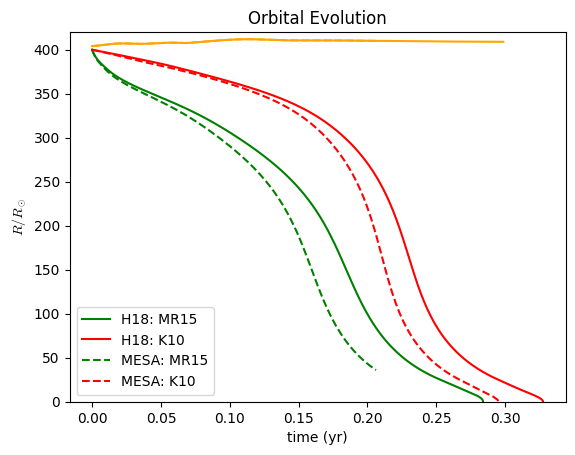

In [83]:
plt.plot(t1_t12*s_to_yr, R_t12[i_t12:f_t12]/R_sun, linestyle = '-', c = 'green', label = r'H18: MR15')
# plt.plot(t2_t12*s_to_yr, R_t12[i_t12:f_t12]/R_sun, linestyle = '-', c = 'green', label = r'H18: MR15 $\eta = 0.1$')
plt.plot(t3_t12*s_to_yr, R_t12[i_t12:f_t12]/R_sun, linestyle = '-', c = 'red', label = r'H18: K10')
plt.plot(hist_mr15.star_age, hist_mr15.aorb/R_sun, linestyle = '--', c = 'green', label = 'MESA: MR15')
plt.plot(hist.star_age[0:n], hist.aorb[0:n]/R_sun, linestyle = '--', c = 'red', label = 'MESA: K10')
plt.plot(hist.star_age, 10**hist.log_R, linestyle = '-', c = 'orange', label = '')
plt.plot(hist_mr15.star_age, 10**hist_mr15.log_R, linestyle = '--', c = 'orange', label = '')
plt.plot
plt.legend()
plt.xlabel('time (yr)')
plt.ylabel(r'$R/R_\odot$')
plt.title('Orbital Evolution')
plt.ylim(0, 420)
plt.show()
plt.close()


# Plotting

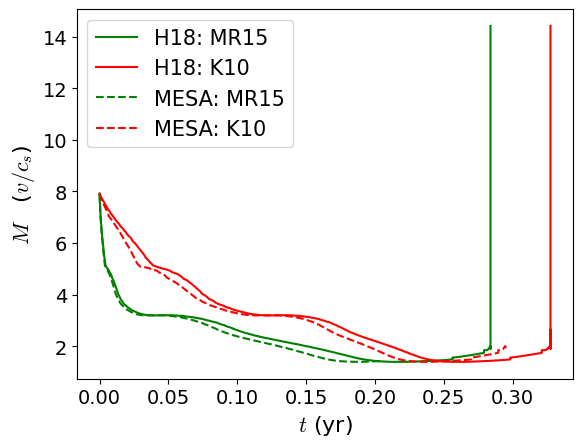

In [79]:
fig, ax1 = plt.subplots()

ax1.plot(t1_t12*s_to_yr, v_t12[i_t12:f_t12]/csound_t12[i_t12:f_t12], linestyle = '-', c = 'green', label = r'H18: MR15')
ax1.plot(t3_t12*s_to_yr, v_t12[i_t12:f_t12]/csound_t12[i_t12:f_t12], linestyle = '-', c = 'red', label = r'H18: K10')

# ax1.plot(t2_t12*s_to_yr, v_t12[i_t12:f_t12]/csound_t12[i_t12:f_t12], linestyle = '-', c = 'red', label = r'H18: $\eta = 0.1$')
ax1.plot(hist_mr15.star_age, hist_mr15.v_rel/hist_mr15.csound, linestyle = '--', c = 'green', label = 'MESA: MR15')
ax1.plot(hist.star_age[0:n], hist.v_rel[0:n]/hist.csound[0:n], linestyle = '--', c = 'red', label = 'MESA: K10')
# ax1.set_xlim(0.1, 10)
ax1.set_xlabel(r'$t$ (yr)', fontsize = 16)
ax1.set_ylabel(r'$M$   ($v/c_s$)', fontsize = 16)
ax1.legend(fontsize = 15)
# ax1.set_xscale('log')
# ax1.set_yscale('log')
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
plt.show()
plt.close()

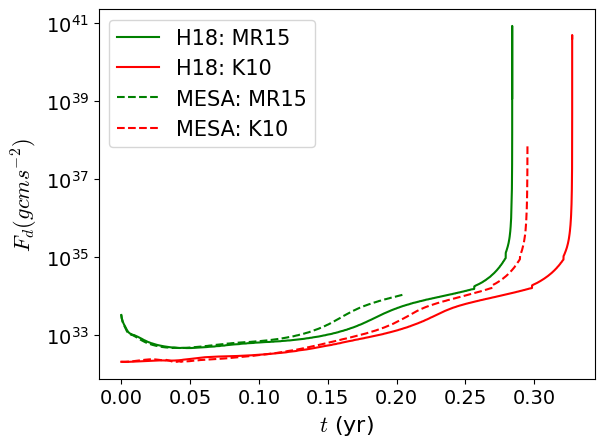

In [80]:
fig, ax1 = plt.subplots()

ax1.plot(t1_t12*s_to_yr, drag1_t12[i_t12:f_t12], linestyle = '-', c = 'green', label = r'H18: MR15')
# ax1.plot(t2_t12*s_to_yr, drag2_t12[i_t12:f_t12], linestyle = '--', c = 'green', label = r'H18: $\eta = 0.1$')
ax1.plot(t3_t12*s_to_yr, drag3_t12[i_t12:f_t12], linestyle = '-', c = 'red', label = r'H18: K10')
ax1.plot(hist_mr15.star_age, hist_mr15.fd, linestyle = '--', c = 'green', label = 'MESA: MR15')
ax1.plot(hist.star_age[0:n], hist.fd[0:n], linestyle = '--', c = 'red', label = 'MESA: K10')
# ax1.set_xlim(0.1, 10)
ax1.set_xlabel(r'$t$ (yr)', fontsize = 16)
ax1.set_ylabel(r'$F_d (g cm s^{-2})$', fontsize = 16)
ax1.legend(fontsize = 15)
# ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
plt.show()
plt.close()

### Plotting the accretion rate of the secondary

NameError: name 't1_b12' is not defined

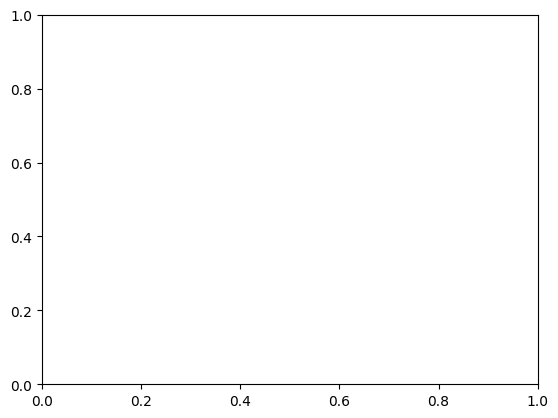

In [81]:
fig, ax1 = plt.subplots()

ax1.plot(t1_b12*s_to_yr, delta_eorb_b12[i_b12:f_b12], linestyle = '-', c = 'orange', label = r'$\eta = 1: base$')
ax1.plot(t1_b12*s_to_yr, -etot_int_b12[i_b12:f_b12], linestyle = '-', c = 'black')
ax1.plot(t2_b12*s_to_yr, delta_eorb_b12[i_b12:f_b12], linestyle = '--', c = 'orange', label = r'$\eta = 0.1: base$')
ax1.plot(t2_b12*s_to_yr, -etot_int_b12[i_b12:f_b12], linestyle = '-', c = 'black')
ax1.plot(t1_t12*s_to_yr, delta_eorb_t12[i_t12:f_t12], linestyle = '-', c = 'green', label = r'$\eta = 1: tip$')
ax1.plot(t1_t12*s_to_yr, -etot_int_t12[i_t12:f_t12], linestyle = '-', c = 'black')
ax1.plot(t2_t12*s_to_yr, delta_eorb_t12[i_t12:f_t12], linestyle = '--', c = 'green', label = r'$\eta = 0.1: tip$')
ax1.plot(t2_t12*s_to_yr, -etot_int_t12[i_t12:f_t12], linestyle = '-', c = 'black')

ax1.set_xlim(0.1, 10)
ax1.set_ylim(1.e45, 1.e49)
ax1.set_xlabel(r'$t$ (yr)', fontsize=16)
ax1.set_ylabel(r'Energy: $E$ (erg)', fontsize=16)
plt.legend(fontsize=15)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
plt.show()
plt.close()


### Plotting the spin evolution of the secondary

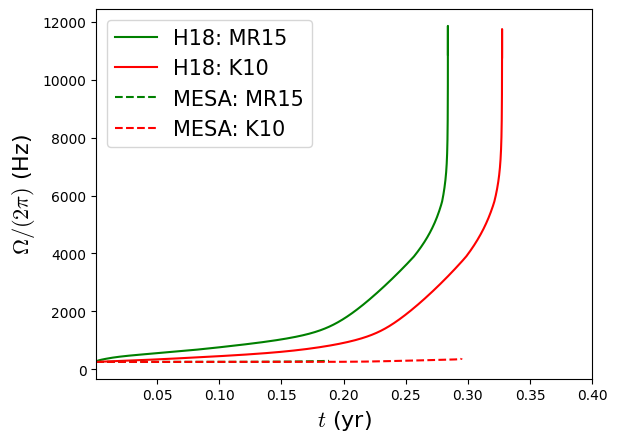

In [ ]:
plt.plot(t1_t12*s_to_yr, omega1_t12/(2*np.pi), linestyle = '-', c = 'green', label = r'H18: MR15')
# plt.plot(t2_t12*s_to_yr, omega2_t12/(2*np.pi), linestyle = '--', c = 'green', label = r'H18: $\eta = 0.1$')
plt.plot(t3_t12*s_to_yr, omega3_1/(2*np.pi), linestyle = '-', c = 'red', label = r'H18: K10')
# plt.plot(t3_t12*s_to_yr, omega3_t12_2/(2*np.pi), linestyle = '--', c = 'red', label = r'H18: K10, $\eta = 0.1$')
plt.plot(hist_mr15.star_age, hist_mr15.omega/(2*np.pi), linestyle = '--', c = 'green', label = 'MESA: MR15')
plt.plot(hist.star_age[0:n], hist.omega[0:n]/(2*np.pi), linestyle = '--', c = 'red', label = 'MESA: K10')
# plt.xscale('log')
plt.legend(fontsize = 15)
plt.xlabel(r'$t$ (yr)', fontsize = 16)
plt.ylabel(r'$\Omega/(2 \pi)$ (Hz)', fontsize = 16)
plt.xlim([0.001, 0.4])
plt.show()
plt.close()

### Plotting the evolution of the strain amplitude of the gravitational waves

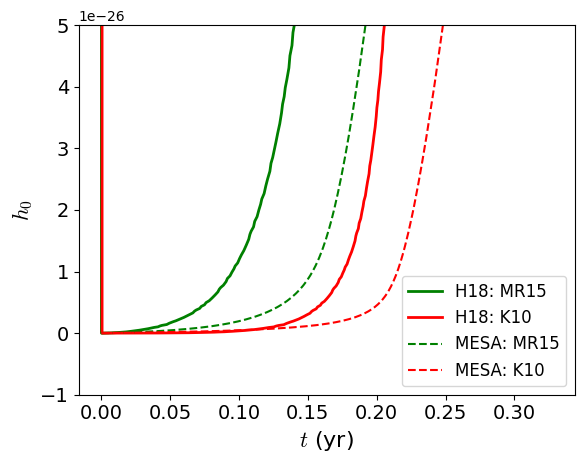

In [82]:

plt.plot(t1_t12*s_to_yr, 2*G_const*(omega1_t12**2)*Q1_t12/((c**4)*2800*pc_to_cm), linestyle = '-', c = 'green', linewidth = 2.0, label = r'H18: MR15')
plt.plot(t3_t12*s_to_yr, 2*G_const*(omega3_1**2)*Q3_1/((c**4)*2800*pc_to_cm), linestyle = '-', c = 'red', linewidth = 2.0, label = r'H18: K10')
# plt.plot(t3_t12*s_to_yr, 2*G_const*(omega3_2**2)*Q3_2/((c**4)*2800*pc_to_cm), linestyle = '--', c = 'red', linewidth = 0.8, label = r'H18: Kim+10, $\eta = 0.1$')
plt.plot(hist_mr15.star_age, 2*G_const*(hist_mr15.omega**2)*hist_mr15.Q/((c**4)*2800*pc_to_cm), linestyle = '--', c = 'green', label = 'MESA: MR15')
plt.plot(hist.star_age[0:n], 2*G_const*(hist.omega[0:n]**2)*hist.Q[0:n]/((c**4)*2800*pc_to_cm), linestyle = '--', c = 'red', label = 'MESA: K10')
# plt.xscale('log')
# plt.yscale('log')
plt.legend(fontsize=12)
plt.xlabel(r'$t$ (yr)', fontsize=16)
plt.ylabel(r'$h_0$', fontsize=16)
# plt.xlim([0.001, 0.3])
# plt.ylim([-0.1e-27, 1e-27])
plt.ylim([-1e-26, 5e-26])
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.show()
plt.close()

<!-- ### Plotting the eddington, hyper-eddington, mr15, and final accretion rate used to see the condition of equation 24 of the paper -->